# Linear Regression Training & Forecast Review

This notebook trains a **LinearRegression** model on historical FX/commodity price data, evaluates test predictions, and visualizes a **recursive forecast** compared to recent actual prices.

- Data source: `yfinance` (via the project's `ml_pipeline.fetch_data` wrapper).
- Model pipeline: `ml_pipeline.linear_regression_model` + `ml_pipeline.generate_forecast`.

> Uses `GC=F` (Gold futures) as the sample instrument; replace with other tickers as needed.

In [4]:
# 1) Import Libraries
import sys
import pathlib

# Ensure the project root is on sys.path so we can import backend modules from within the notebooks folder
PROJECT_ROOT = pathlib.Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from backend.apis import ml_pipeline

# Ensure inline plotting works if running in a notebook environment
%matplotlib inline

## 2) Load Historical Price Data
Fetch OHLCV data for GC=F (gold futures) and inspect the dataframe.

In [10]:
start_date = "2025-12-15"
end_date = "2026-03-15"
ticker = "GC=F"  # gold futures (yfinance)

data = ml_pipeline.fetch_data(start_date, end_date, ticker)

data.head()

[*********************100%***********************]  1 of 1 completed

Price,Close,High,Low,Open,Volume,Adj Close
Date,,,,,,
2025-12-15,4306.700195,4349.200195,4292.899902,4308.299805,854,4306.700195
2025-12-16,4304.500000,4321.399902,4270.500000,4270.500000,1796,4304.500000
2025-12-17,4347.500000,4351.399902,4308.500000,4308.500000,2169,4347.500000
2025-12-18,4339.500000,4348.100098,4328.200195,4331.000000,705,4339.500000
2025-12-19,4361.399902,4361.399902,4350.100098,4350.100098,1065,4361.399902


## 3) Feature Engineering
Apply the pipeline's `feature_engineering` to create technical indicators and lags.

In [11]:
engineered = ml_pipeline.feature_engineering(data.copy())
engineered.head()

Price,Close,High,Low,Open,Volume,Adj Close,SMA_10,SMA_50,EMA_10,EMA_50,...,Lag_1,Lag_2,Lag_3,Lag_4,Lag_5,Volatility,BB_MA,BB_Std,BB_Upper,BB_Lower
Date,,,,,,,,,,,,,,,,,,,,,
2026-02-27,5230.500000,5280.000000,5176.700195,5186.700195,354,5230.500000,5059.369971,4744.277988,5093.333323,4809.530851,...,5176.500000,5206.399902,5155.799805,5204.700195,5059.299805,60.373880,5000.574976,167.786047,5336.147070,4665.002882
2026-03-02,5294.399902,5405.000000,5266.299805,5346.600098,72,5294.399902,5090.049951,4762.753984,5118.272719,4826.039445,...,5230.500000,5176.500000,5206.399902,5155.799805,5204.700195,28.995538,4996.179980,159.993011,5316.166002,4676.193959
2026-03-03,5107.399902,5303.799805,5023.000000,5298.700195,1776,5107.399902,5117.289941,4782.551982,5150.295843,4844.406522,...,5294.399902,5230.500000,5176.500000,5206.399902,5155.799805,53.803986,5025.204980,158.738708,5342.682397,4707.727564
2026-03-04,5120.200195,5180.200195,5117.200195,5130.700195,679,5120.200195,5139.739941,4797.749980,5142.496581,4854.719988,...,5107.399902,5294.399902,5230.500000,5176.500000,5206.399902,68.853780,5049.449976,128.060406,5305.570787,4793.329165
2026-03-05,5065.299805,5169.500000,5054.700195,5169.500000,1701,5065.299805,5153.109961,4813.363984,5138.442693,4865.130976,...,5120.200195,5107.399902,5294.399902,5230.500000,5176.500000,77.987865,5060.274976,124.183409,5308.641794,4811.908157


## 4) Train/Test Split
Split the engineered dataset into an 80/20 train/test split.

In [12]:
train, test = ml_pipeline.split_data(engineered, train_size=0.8)
print("Train rows:", len(train), "Test rows:", len(test))

train["Close"].tail(), test["Close"].head()

Train rows: 8 Test rows: 3


(Date
 2026-03-04    5120.200195
 2026-03-05    5065.299805
 2026-03-06    5146.100098
 2026-03-09    5091.500000
 2026-03-10    5229.700195
 Name: Close, dtype: float64,
 Date
 2026-03-11    5167.399902
 2026-03-12    5115.799805
 2026-03-13    5061.700195
 Name: Close, dtype: float64)

## 5) Train Linear Regression Model
Train the model (with hyperparameter tuning) and save the trained model and feature metadata.

In [13]:
result = ml_pipeline.linear_regression_model(train, test, ticker=ticker)
print("Training result:", result)

Training LinearRegression model with hyperparameter tuning...
--- LinearRegression --- RMSE: 338.6874  MAE: 208.2887  MAPE: 0.0411
Updated metadata for LinearRegression in GCF
Training result: model_name='LinearRegression' model=ElasticNet(alpha=0.1) rmse=338.6873743436862 mae=208.2886594498335 mape=0.04110276662937982


C:\Users\jojo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.482e-01, tolerance: 2.042e-01
  model = cd_fast.enet_coordinate_descent(
C:\Users\jojo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.202e+00, tolerance: 2.422e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\jojo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-p

## 6) Evaluate & Plot Predictions vs Actual
Compute RMSE/MAE/MAPE and visualize actual vs predicted close prices on the test set.

RMSE=338.6874, MAE=208.2887, MAPE=0.0411


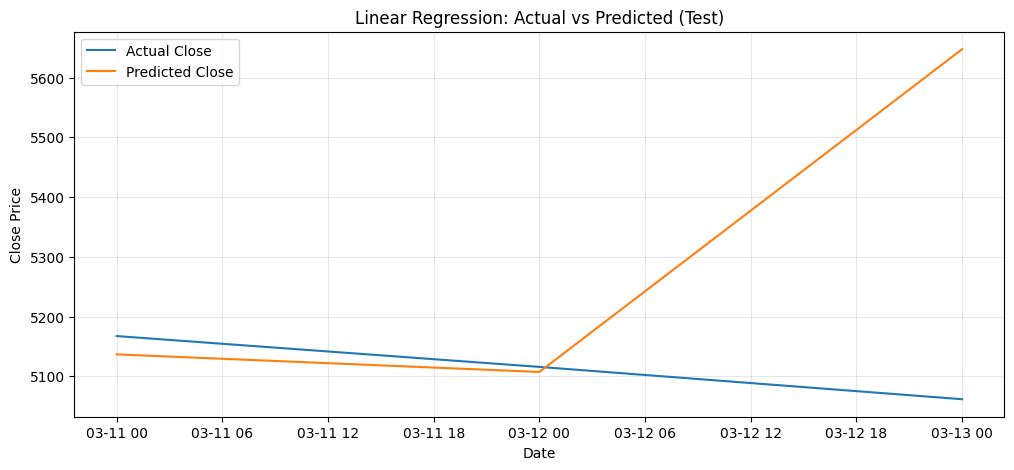

In [15]:
# Load model and metadata
folder, sym = ml_pipeline.get_ticker_folder(ticker)
model = joblib.load(f"{folder}/LinearRegression_{sym}.pkl")
meta = joblib.load(f"{folder}/LinearRegression_{sym}_data.pkl")

feature_cols = meta["feature_cols"]

X_test = test[feature_cols]
y_test = test["Close"]

preds = model.predict(X_test)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
rmse = mean_squared_error(y_test, preds)
rmse = np.sqrt(rmse)
mae = mean_absolute_error(y_test, preds)
mape = mean_absolute_percentage_error(y_test, preds)

print(f"RMSE={rmse:.4f}, MAE={mae:.4f}, MAPE={mape:.4f}")

plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test.values, label="Actual Close", color="tab:blue")
plt.plot(y_test.index, preds, label="Predicted Close", color="tab:orange")
plt.title("Linear Regression: Actual vs Predicted (Test)")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(alpha=0.3)

## 7) Forecast Future Prices with Recursive Lag Features
Use `generate_forecast` to forecast the next 30 days and capture trend continuity.

In [ ]:
forecast_steps = 30
last_date = test.index[-1].strftime("%Y-%m-%d")

forecast = ml_pipeline.generate_forecast("LinearRegression", ticker, last_date, steps=forecast_steps)
forecast_df = pd.DataFrame({
    "date": pd.to_datetime(forecast["dates"]),
    "forecast": forecast["predictions"]
})

forecast_df.head()

## 8) Visualize Forecast Trend Against Actual Prices
Plot the forecast versus the most recent actual values to see how well the trend continues.

In [ ]:
history_window = 30
recent_actual = data["Close"].tail(history_window)

plt.figure(figsize=(12, 5))
plt.plot(recent_actual.index, recent_actual.values, label="Recent Actual Close", color="tab:blue")
plt.plot(forecast_df["date"], forecast_df["forecast"], label="Forecast", color="tab:orange", linestyle="--")
plt.title("Forecast vs Recent Actuals")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(alpha=0.3)